#***Librerias***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.stats as stats
from sklearn.naive_bayes import GaussianNB #importa el algoritmo
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt


#**Dataset - Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/Mydrive')

file_path = '/content/Mydrive/MyDrive/Inteligencia Artificial I/PROYECTO-IA/ObesityDataSet.csv'

df = pd.read_csv(file_path)


Mounted at /content/Mydrive


##**Filtrado**

In [ ]:
#Detectar nulos en los registros
nulos_por_columna = pd.isnull(df).sum()


#**Clasificador Naive Bayes gaussiano (GNB)**


***¿Qué son los clasificadores Naive Bayes?***

Los clasificadores Naive Bayes son algoritmos de aprendizaje automático supervisado que se utilizan para resolver problemas de clasificación. El término «ingenuo» proviene del hecho de que estos clasificadores asumen que todas las características de un modelo son independientes, es decir, que no se afectan entre sí. También asumen que cada característica contribuye por igual al resultado del modelo, por lo que no pueden discernir las características más importantes.   

Estos clasificadores contienen pocos parámetros, lo que los hace más sencillos y rápidos que otros tipos.

<br/>

***¿Qué es la distribución gaussiana?***

La distribución gaussiana también se denomina  distribución normal . La distribución normal es un modelo estadístico que describe la distribución de variables aleatorias continuas en la naturaleza y se define por su curva en forma de campana. Las dos características más importantes de la distribución normal son la media (μ) y la desviación estándar (σ). La media es el valor promedio de la distribución, y la desviación estándar es la dispersión de la distribución alrededor de la media.


Fuente: [GNB](https://builtin.com/artificial-intelligence/gaussian-naive-bayes)

<br/>

***¿Qué es la Matriz de la Confusión?***

La matriz de confusión es una herramienta utilizada para evaluar el rendimiento de un modelo y se representa visualmente en forma de tabla. Proporciona una visión más profunda a los profesionales de los datos sobre el rendimiento, los errores y los puntos débiles del modelo.



Fuente: [Matriz de Confusion](https://www.datacamp.com/es/tutorial/what-is-a-confusion-matrix-in-machine-learning)

<br/>

***¿Qué es la validación cruzada K-Fold?***

La validación cruzada K-Fold es una técnica robusta que se utiliza para evaluar el rendimiento de los modelos de aprendizaje automático. Ayuda a garantizar que el modelo generaliza bien a los datos no vistos, utilizando diferentes porciones del conjunto de datos para el entrenamiento y la prueba en múltiples iteraciones.

Fuente: [Validacion cruzada](https://www.datacamp.com/es/tutorial/k-fold-cross-validation)

<br/>

**Metricas de evaluacion de modelo de clasificación.**

| Métrica      | Responde a la pregunta                                  |
| ------------ | ------------------------------------------------------- |
| Precision    | ¿De lo que predije de esta clase, cuántos estaban bien? |
| Recall       | ¿De lo que realmente era de esta clase, cuánto detecté? |
| F1           | ¿Qué tan equilibrado está entre precisión y recall?     |
| Support      | ¿Cuántos datos hay de esa clase?                        |
| Accuracy     | ¿Cuánto acerté en total del dataset?                    |
| Macro avg    | Promedio dando el mismo peso a cada clase               |
| Weighted avg | Promedio considerando cuántos datos tiene cada clase    |

Fuente: [Metricas](https://www.geeksforgeeks.org/machine-learning/metrics-for-machine-learning-model/)



#**Conversión categoricas a numericas**

In [ ]:
#NOTA: Ten encuenta que solo se ejecuta una vez para visualizar, ya que si lo haces nuevamente ya las actegoricas son numericas

#   columnas categóricas
df=df.drop("SMOKE",axis=1)
categorical_cols = df.select_dtypes(include=['object']).columns
print("Columnas categóricas:", categorical_cols.tolist())

# Diccionario para guardar los mapeos
mapeos = {}

# Transformar cada columna categórica y guardar el mapeo
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = df[col].fillna('missing')  # para manejar nulos
    df[col] = le.fit_transform(df[col])
    mapeos[col] = dict(zip(le.classes_, le.transform(le.classes_)))

# Mostrar los mapeos
print("\nMapeos de columnas categóricas:\n")
for col, mapping in mapeos.items():
    print(f"Columna: {col}")
    for categoria, valor in mapping.items():
        print(f"  {categoria}: {valor}")
    print("-" * 40)



Columnas categóricas: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']

Mapeos de columnas categóricas:

Columna: Gender
  Female: 0
  Male: 1
----------------------------------------
Columna: family_history_with_overweight
  no: 0
  yes: 1
----------------------------------------
Columna: FAVC
  no: 0
  yes: 1
----------------------------------------
Columna: CAEC
  Always: 0
  Frequently: 1
  Sometimes: 2
  no: 3
----------------------------------------
Columna: SCC
  no: 0
  yes: 1
----------------------------------------
Columna: CALC
  Always: 0
  Frequently: 1
  Sometimes: 2
  no: 3
----------------------------------------
Columna: MTRANS
  Automobile: 0
  Bike: 1
  Motorbike: 2
  Public_Transportation: 3
  Walking: 4
----------------------------------------
Columna: NObeyesdad
  Insufficient_Weight: 0
  Normal_Weight: 1
  Obesity_Type_I: 2
  Obesity_Type_II: 3
  Obesity_Type_III: 4
  Overweight_Level_I: 5
  Overweight_Level_II: 

#**The Naive Gaussian Bayes**

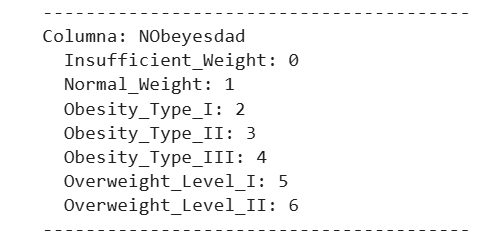

**THE NAIVE GAUSSIAN BAYES: Media poblacion para test y media para train, sin mezclar los registros.**

In [ ]:

X = df.values[:,:-1]
y = df.values[:,-1]

est=GaussianNB()

n = int(len(X)/2)
#entreno el modelo con la mitad de los datos
est.fit(X[:n], y[:n])
prediction=est.predict(X[n:])

print("%.3f"%accuracy_score(prediction, y[n:]))
print("Reporte de clasificacion")
print(classification_report(prediction, y[n:]))
print("Matriz de confusión")
print(confusion_matrix(y[n:],prediction))


0.672
Reporte de clasificacion
              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00        20
         2.0       0.24      0.68      0.36       109
         3.0       0.76      0.96      0.84       226
         4.0       1.00      0.92      0.96       338
         5.0       0.00      0.00      0.00        65
         6.0       0.70      0.36      0.48       298

    accuracy                           0.67      1056
   macro avg       0.45      0.49      0.44      1056
weighted avg       0.70      0.67      0.66      1056

Matriz de confusión
[[  0   0   0   0   0   0]
 [  0  74  10  13  47 160]
 [  0  34 216   6   0  30]
 [  0   0   0 312   0   0]
 [  0   0   0   0   0   0]
 [ 20   1   0   7  18 108]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


:**THE NAIVE GAUSSIAN BAYES: Media poblacion para test y media para train, mezclando.**

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, shuffle=True
)



est = GaussianNB()
est.fit(X_train, y_train)
pred = est.predict(X_test)

acc = accuracy_score(y_test, pred)
print(f"accuracy {acc:.3f}")
print("Reporte de clasificacion")
print(classification_report(y_test, pred))
print("Matriz de confusión")
print(confusion_matrix(y_test, pred))


accuracy 0.615
Reporte de clasificacion
              precision    recall  f1-score   support

         0.0       0.66      0.73      0.70       135
         1.0       0.57      0.38      0.46       151
         2.0       0.37      0.68      0.48       170
         3.0       0.71      0.89      0.79       153
         4.0       0.99      0.99      0.99       163
         5.0       0.51      0.25      0.33       141
         6.0       0.67      0.31      0.42       143

    accuracy                           0.61      1056
   macro avg       0.64      0.60      0.59      1056
weighted avg       0.64      0.61      0.60      1056

Matriz de confusión
[[ 99  11  22   0   0   3   0]
 [ 48  58  18   0   1  17   9]
 [  0   1 115  40   1   7   6]
 [  0   0  15 136   0   1   1]
 [  0   0   1   0 162   0   0]
 [  2  25  73   0   0  35   6]
 [  0   7  70  16   0   6  44]]


***CONCLUSIÓN:***  "Modelo con desempeño moderado, esto desde la prediccion del modelo (accuracy)".

- Naive Bayes asume que todas las variables son independientes entre sí, pero en este dataset hay variables que se correlacionadas, por ende, ese principio que sigue es lo que me determina la poca precision, al igual que la distribucion que siguen las caracteristicas, ya que no son normales (distribución gaussiana).

- Tambien se puede resaltar que apesar de los cambios en el tipo de seleccion en los datos de entrenamiento y testeo no aportan un gran cambio en el modelo, esto por la naturaleza de los datos.

- Adicionando a lo anterior, la division de test y train no es la mas optima (50/50).
Si solo usas el 50% del dataset para entrenar, el modelo aprende menos patrones, se ajusta peor (sub-ajuste "underfitting").


NOTA: Cuando calculamos la matriz de confusion y el reporte de metricas, podemos ver que en algunas clases, no realizo ni una predicion, esto se debe a la division de test y train.

**THE NAIVE GAUSSIAN BAYES: 20% poblacion para test y 80% para train, mezclando.**

1688
423


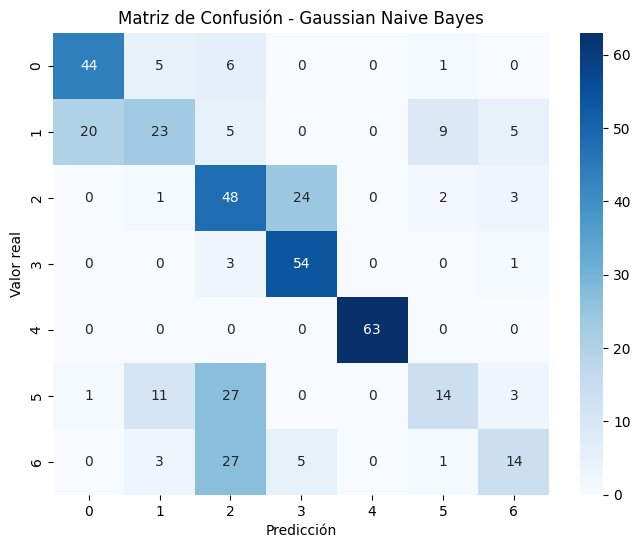

0.615
Reporte de clasificacion
              precision    recall  f1-score   support

         0.0       0.79      0.68      0.73        65
         1.0       0.37      0.53      0.44        43
         2.0       0.62      0.41      0.49       116
         3.0       0.93      0.65      0.77        83
         4.0       1.00      1.00      1.00        63
         5.0       0.25      0.52      0.34        27
         6.0       0.28      0.54      0.37        26

    accuracy                           0.61       423
   macro avg       0.60      0.62      0.59       423
weighted avg       0.69      0.61      0.64       423

Matriz de confusión
[[44  5  6  0  0  1  0]
 [20 23  5  0  0  9  5]
 [ 0  1 48 24  0  2  3]
 [ 0  0  3 54  0  0  1]
 [ 0  0  0  0 63  0  0]
 [ 1 11 27  0  0 14  3]
 [ 0  3 27  5  0  1 14]]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(len(X_train))
print(len(X_test))
est=GaussianNB()


#entreno el modelo con la mitad de los datos
est.fit(X_train, y_train)
prediction=est.predict(X_test)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generar matriz de confusión
cm = confusion_matrix(y_test, prediction)

# Visualización gráfica
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")  # Muestra los valores enteros
plt.title("Matriz de Confusión - Gaussian Naive Bayes")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()


print("%.3f"%accuracy_score(prediction, y_test))
print("Reporte de clasificacion")
print(classification_report(prediction, y_test))
print("Matriz de confusión")
print(confusion_matrix(y_test,prediction))

***CONCLUSIÓN***


Aplicar datos categóricos con GaussianNB no es ideal, porque simplemente asigna probabilidades como si fueran números continuos.

En este caso, aunque se aumente los datos de entrenamiento, el modelo no mejora porque las suposiciones no se cumplen (independencia, y distribución gaussiana).

[0.56040111 0.55351342 0.57448084 0.57615299 0.58905281 0.59161574
 0.60239006 0.60492683 0.60818145 0.61332485] [0.49885501 0.52468555 0.5606333  0.56207331 0.56709749 0.57148781
 0.57879953 0.57594753 0.57990544 0.58891717]


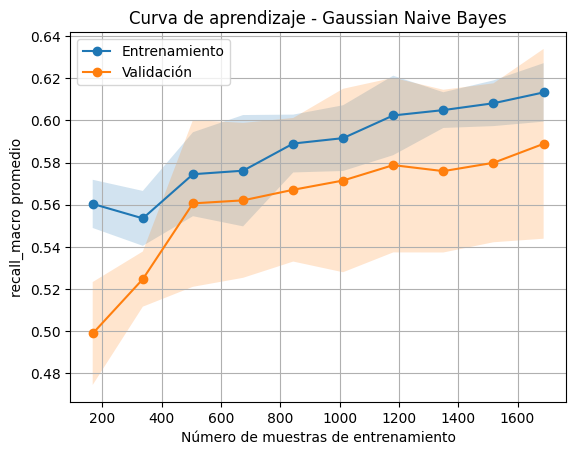

In [ ]:
#curva de aprendizaje

# Calcular curva de aprendizaje

#train_sizes son los tamaños
#train_scores Son los puntajes (accuracy) del modelo evaluado
#sobre los datos de entrenamiento, para cada tamaño en train_sizes
#test_scores Son los puntajes (accuracy) del modelo evaluado
#sobre los datos de testeo, para cada tamaño en train_sizes

train_sizes, train_scores, test_scores = learning_curve(
    est,
    X,
    y,
    cv=5,  # numero de particiones validacion cruzada
    scoring='recall_macro',  # metrica a evaluar modelo
    train_sizes=np.linspace(0.1, 1.0, 10),  # tamaño de las particiones de train (10 valores)
    shuffle=True,
    random_state=42
)

# Promedio y desviación estándar
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
test_mean  = np.mean(test_scores, axis=1)
test_std   = np.std(test_scores, axis=1)
print(train_mean, test_mean)

# gráfica
plt.figure()
plt.plot(train_sizes, train_mean, marker='o', label='Entrenamiento')
plt.plot(train_sizes, test_mean, marker='o', label='Validación')

# === SOMBRA DE DESVIACIÓN ESTÁNDAR (AQUÍ ESTABA LO QUE FALTABA) ===
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2)

plt.title("Curva de aprendizaje - Gaussian Naive Bayes")
plt.xlabel("Número de muestras de entrenamiento")
plt.ylabel("recall_macro promedio")
plt.legend()
plt.grid(True)
plt.show()


***Conclusión***
Comparando los resultados de los modelos, no hay sobreajuste ya que no difieren mucho, es decir, no memorizo, esta prediciendo, pero con respecto a la métrica a evaluar no le va bien.

Sobreajuste: Si hay una diferencia (6 al 15% hay un pquito) y ya si empieza aproximadamente con una diferencia de 15% en adelante si es sobreajuste, es decir, el modelo aprende tan bien los datos de entrenamiento que memoriza, pero no generaliza.


Fuente: [Curva de aprendizaje](https://www.datacamp.com/es/tutorial/what-is-underfitting)

#**The Naive Gaussian Bayes**: Excluyendo algunas categoricas.

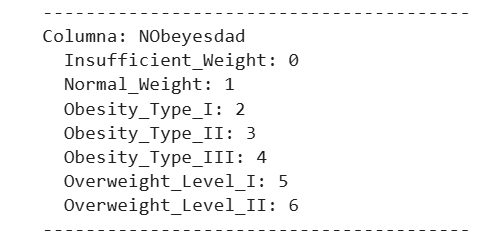

Se excluyeron CAEC, CALC, MTRANS.

0.686
Reporte de clasificacion
              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00        21
         2.0       0.30      0.59      0.40       154
         3.0       0.77      0.96      0.85       231
         4.0       1.00      0.92      0.96       338
         5.0       0.00      0.00      0.00        98
         6.0       0.65      0.47      0.54       214

    accuracy                           0.69      1056
   macro avg       0.45      0.49      0.46      1056
weighted avg       0.66      0.69      0.66      1056

Matriz de confusión
[[  0   0   0   0   0   0]
 [  0  91  10  13  78 112]
 [  0  57 221   6   0   2]
 [  0   0   0 312   0   0]
 [  0   0   0   0   0   0]
 [ 21   6   0   7  20 100]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


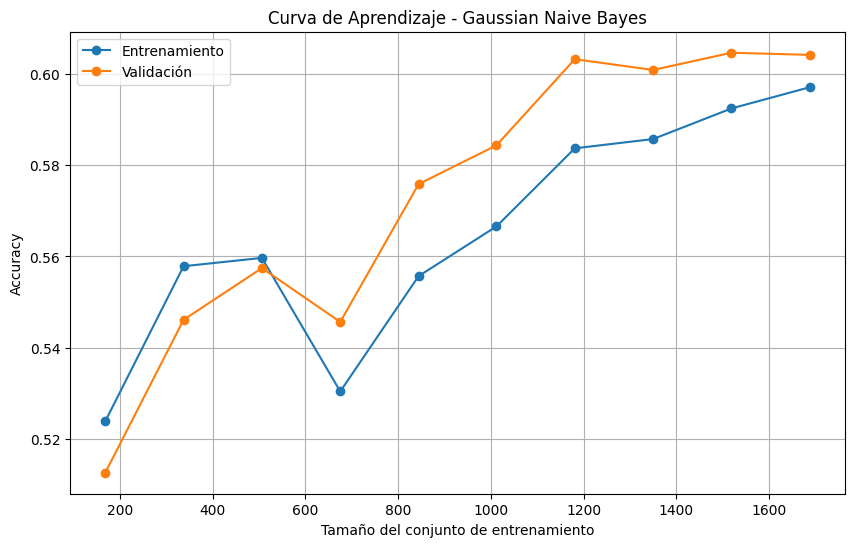

In [ ]:
df_copy=df.drop(["CAEC", "CALC", "MTRANS"],axis=1)

X = df_copy.values[:,:-1]
y = df_copy.values[:,-1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

est=GaussianNB()

n = int(len(X)/2)
#entreno el modelo con la mitad de los datos
est.fit(X[:n], y[:n])
prediction=est.predict(X[n:])

print("%.3f"%accuracy_score(prediction, y[n:]))

print("Reporte de clasificacion")
print(classification_report(prediction, y[n:]))
print("Matriz de confusión")
print(confusion_matrix(y[n:],prediction))


from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import learning_curve
from sklearn.model_selection import ShuffleSplit
import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# CURVA DE APRENDIZAJE
# -------------------------

# X = features (sin CAEC, CALC, MTRANS)
# y = etiquetas (clase objetivo)
# asegúrate de que X y y ya estén definidos como en tu script anterior

est = GaussianNB()

# configuracion del cross-validation para mezclar los datos
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

train_sizes, train_scores, test_scores = learning_curve(
    est,
    X,
    y,
    cv=cv,
    train_sizes=np.linspace(0.1, 1.0, 10),  # 10 tamaños de entrenamiento
    scoring="accuracy"
)

# promedios por cada tamaño
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

# -------------------------
# GRAFICAR LA CURVA
# -------------------------

plt.figure(figsize=(10,6))
plt.title("Curva de Aprendizaje - Gaussian Naive Bayes")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Accuracy")

plt.plot(train_sizes, train_scores_mean, marker='o', label="Entrenamiento")
plt.plot(train_sizes, test_scores_mean, marker='o', label="Validación")

plt.grid(True)
plt.legend(loc="best")
plt.show()



CONCLUSIÓN

Al quitar del entrenamiento y testeo variables que se correlacionan y aportan a la decision de clasificacion, se ve una minima mejoria, al reducir esa carga de oposición a los principios del modelo.